Columns in dataset:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']

Dataset shape:
(20640, 10)

Feature shape: (20640, 12)
Target shape : (20640, 1)

Training samples: 16512
Testing samples : 4128
Iteration    0 | Loss: 28148711615.5157
Iteration  100 | Loss: 5808128901.6727
Iteration  200 | Loss: 2979975718.6082
Iteration  300 | Loss: 2576792584.2825
Iteration  400 | Loss: 2499389867.4603
Iteration  500 | Loss: 2471125824.7238
Iteration  600 | Loss: 2453227034.4581
Iteration  700 | Loss: 2439398464.2304
Iteration  800 | Loss: 2428124054.4083
Iteration  900 | Loss: 2418746610.9837

Gradient Descent Results

Final weights (theta):
[ 2.07185749e+05 -1.75500342e+04 -1.62891489e+04  1.45964139e+04
  4.28529588e+03  1.88535556e+04 -3.25459031e+04  1.58392451e+04
  7.20495096e+04 -3.02425493e+04  2.40680595e+03  1.53082681e+02
  3.41626449e+03]

Test MSE : 4971010329.4080
T

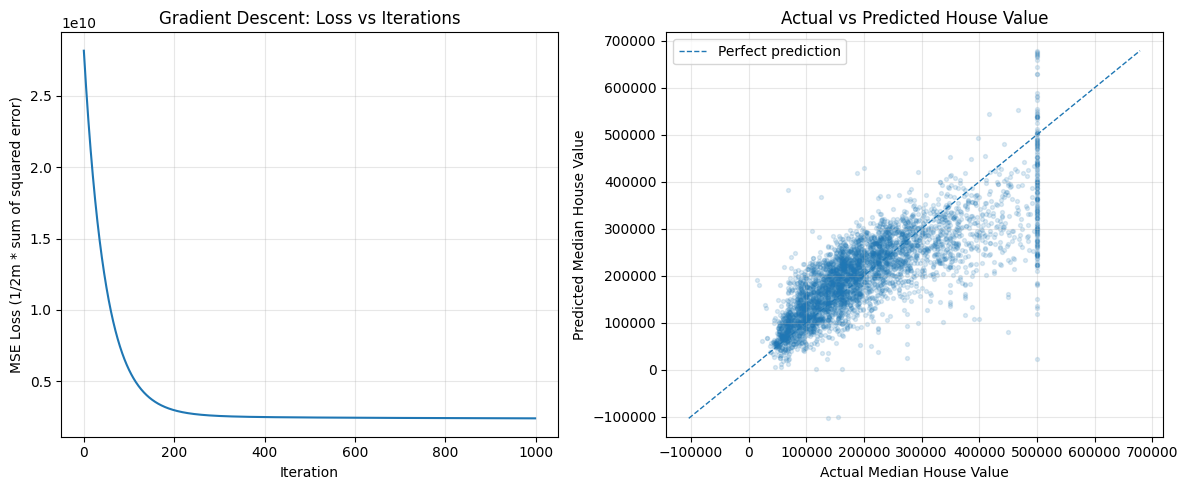

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression



df = pd.read_csv("/content/housing.csv")


df.columns = df.columns.str.strip()

print("Columns in dataset:")
print(df.columns.tolist())

print("\nDataset shape:")
print(df.shape)


target_col = "median_house_value"


feature_df = df.drop(
    columns=[target_col]
)


feature_df = pd.get_dummies(
    feature_df,
    columns=["ocean_proximity"],
    drop_first=True,
    dtype=float
)

feature_df = feature_df.fillna(
    feature_df.median()
)

X = feature_df.values

y = df[target_col].values.reshape(-1, 1)


print("\nFeature shape:", X.shape)
print("Target shape :", y.shape)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print("\nTraining samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


X_train_b = np.c_[
    np.ones((X_train.shape[0], 1)),
    X_train
]

X_test_b = np.c_[
    np.ones((X_test.shape[0], 1)),
    X_test
]


def gradient_descent(
    X,
    y,
    lr=0.01,
    n_iters=1000
):

    m, n = X.shape

    theta = np.zeros((n, 1))

    losses = []

    for i in range(n_iters):


        y_pred = X @ theta
        error = y_pred - y

        loss = (
            1 / (2 * m)
        ) * np.sum(error ** 2)

        losses.append(loss)




        gradient = (
            1 / m
        ) * (X.T @ error)




        theta = theta - lr * gradient




        if i % 100 == 0:

            print(
                f"Iteration {i:4d} | Loss: {loss:.4f}"
            )


    return theta, losses



theta, losses = gradient_descent(
    X_train_b,
    y_train,
    lr=0.01,
    n_iters=1000
)


y_pred = X_test_b @ theta

mse = mean_squared_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)


print("\n==========================================")
print("Gradient Descent Results")
print("==========================================")

print("\nFinal weights (theta):")
print(theta.ravel())

print(f"\nTest MSE : {mse:.4f}")
print(f"Test R^2 : {r2:.4f}")

sk_model = LinearRegression()

sk_model.fit(
    X_train,
    y_train.ravel()
)

sk_pred = sk_model.predict(
    X_test
)


sk_mse = mean_squared_error(
    y_test,
    sk_pred
)

sk_r2 = r2_score(
    y_test,
    sk_pred
)


print("\n==========================================")
print("Sklearn Linear Regression Results")
print("==========================================")

print(f"Sklearn MSE : {sk_mse:.4f}")
print(f"Sklearn R^2 : {sk_r2:.4f}")


print("\n==========================================")
print("Model Comparison")
print("==========================================")

print(
    f"Gradient Descent -> MSE: {mse:.4f}, R²: {r2:.4f}"
)

print(
    f"Sklearn           -> MSE: {sk_mse:.4f}, R²: {sk_r2:.4f}"
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)


axes[0].plot(
    range(len(losses)),
    losses
)

axes[0].set_title(
    "Gradient Descent: Loss vs Iterations"
)

axes[0].set_xlabel(
    "Iteration"
)

axes[0].set_ylabel(
    "MSE Loss (1/2m * sum of squared error)"
)

axes[0].grid(
    alpha=0.3
)


axes[1].scatter(
    y_test,
    y_pred,
    alpha=0.15,
    s=8
)

lims = [
    min(
        y_test.min(),
        y_pred.min()
    ),
    max(
        y_test.max(),
        y_pred.max()
    )
]


axes[1].plot(
    lims,
    lims,
    linestyle="--",
    linewidth=1,
    label="Perfect prediction"
)


axes[1].set_title(
    "Actual vs Predicted House Value"
)

axes[1].set_xlabel(
    "Actual Median House Value"
)

axes[1].set_ylabel(
    "Predicted Median House Value"
)

axes[1].legend()

axes[1].grid(
    alpha=0.3
)


plt.tight_layout()

plt.savefig(
    "housing_gradient_descent_plots.png",
    dpi=150
)

print(
    "\nSaved plots to housing_gradient_descent_plots.png"
)

plt.show()